In [2]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import optuna
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor
from Preprocess import preprocess_data_window_same_boolean
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)


In [3]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
data_orig     = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")


In [4]:
# ── Cell 3: Preprocessing ────────────────────────────────────────────────────
n_previous_events = 20
n_qubits_base = 6

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window_same_boolean(
    filtered_time, data_orig, n_previous_events
)


display(X_train.iloc[0])
display(y_train.iloc[0])

X shape:  (2822, 126)
y shape:  (2822,)


tide_deriv-0         -0.446950
form_fac-0            0.995725
time_since-0      40665.000000
slip_size-0          -1.896859
high_t_evt-0          0.000000
                      ...     
form_fac-20           3.513232
time_since-20     83565.000000
slip_size-20         -0.929738
high_t_evt-20         1.000000
tide_height-20       82.126217
Name: 339, Length: 126, dtype: float64

0

In [5]:
# ── Cell 4: Config ───────────────────────────────────────────────────────────
QRC_CONFIG = {
    "num_layers_per_event": 2, 
    "shots":4096,
    "n_iterations": 5,
    "top_k": 3,
    "correlation_threshold": 0.0,
    "random_seed": 42,
}

CLASSICAL_MODEL_NAME = "XGBoost"
n_previous_events = 20

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)


QRC Config: {'num_layers_per_event': 2, 'shots': 4096, 'n_iterations': 5, 'top_k': 3, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: XGBoost


In [6]:
# ── Cell 5: Scaling ─────────────────────────────────────────────────────────
def scale_to_pi_range(X_train, X_val, X_test):
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0

    def transform(X):
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


X_train_sel = X_train.to_numpy()
X_val_sel   = X_val.to_numpy()
X_test_sel  = X_test.to_numpy()

X_train_q, X_val_q, X_test_q = scale_to_pi_range(X_train_sel, X_val_sel, X_test_sel)

# Convert targets to numpy once here for use throughout
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

n_qubits       = n_qubits_base
n_states       = 2 ** n_qubits
n_total_events = n_previous_events + 1

print(f"Input to quantum circuit: {X_train_q.shape}")
print(f"n_qubits: {n_qubits}, n_states: {n_states}")
print(f"Total events per sample: {n_total_events}")


Input to quantum circuit: (1692, 126)
n_qubits: 6, n_states: 64
Total events per sample: 21


In [7]:
# ── Cell 6: Raw features for classical XGBoost path ───
X_train_raw = X_train.to_numpy()
X_val_raw   = X_val.to_numpy()
X_test_raw  = X_test.to_numpy()


In [8]:
# ── Cell 7: FC-TFI Hamiltonian ────────────────────────────────────────────────
def generate_ising_params(n_qubits, rng, J_std=0.5, h=1.0, t=0.5):
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            J[i, j] = rng.normal(0, J_std)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=3): 
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * J[i, j] * dt, j)
                    qc.cx(i, j)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def encode_rotations(qc, data_sample, n_qubits):
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)


def build_reservoir_circuit_rotations(data_sample, ising_params, num_layers, n_qubits):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)

    for i in range(n_qubits):
        qc.h(i)

    encode_rotations(qc, data_sample, n_qubits)
    qc.barrier()

    for layer in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

        encode_rotations(qc, data_sample, n_qubits)
        qc.barrier()

        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

    return qc


def generate_random_angles(num_layers, n_qubits, rng):
    return generate_ising_params(n_qubits, rng)


In [9]:
# ── Cell 8: Pauli runner — quantum features only, no classical concatenation ───
def get_pauli_expectations(circuit_base, n_qubits, shots, simulator):
    expectations = np.zeros(3 * n_qubits)

    for basis_idx, basis in enumerate(['Z', 'X', 'Y']):
        qc_meas = circuit_base.copy()

        if basis == 'X':
            for i in range(n_qubits):
                qc_meas.h(i)
        elif basis == 'Y':
            for i in range(n_qubits):
                qc_meas.sdg(i)
                qc_meas.h(i)

        qc_meas.measure_all()
        result = simulator.run(qc_meas, shots=shots).result()
        counts = result.get_counts()

        for bitstring, count in counts.items():
            bits = bitstring.replace(" ", "")
            for qubit_idx in range(n_qubits):
                bit = int(bits[n_qubits - 1 - qubit_idx])
                expectations[basis_idx * n_qubits + qubit_idx] += (
                    (1 - 2 * bit) * count / shots
                )

    zz_correlators = np.zeros(n_qubits)
    qc_zz = circuit_base.copy()
    qc_zz.measure_all()
    result_zz = simulator.run(qc_zz, shots=shots).result()
    counts_zz = result_zz.get_counts()

    for bitstring, count in counts_zz.items():
        bits = bitstring.replace(" ", "")
        for i in range(n_qubits):
            j = (i + 1) % n_qubits
            bit_i = int(bits[n_qubits - 1 - i])
            bit_j = int(bits[n_qubits - 1 - j])
            zz_correlators[i] += (
                (1 - 2*bit_i) * (1 - 2*bit_j) * count / shots
            )

    return np.concatenate([expectations, zz_correlators])


def run_quantum_reservoir_pauli(
    X_data, angle_bank, num_layers, n_qubits, n_total_events, shots
):
    if hasattr(X_data, 'values'):
        X_data = X_data.to_numpy()

    m         = X_data.shape[0]
    n_obs     = 3 * n_qubits + n_qubits  
    simulator = AerSimulator()
    pauli_matrix = np.zeros((m, n_total_events * n_obs))

    for event_idx in range(n_total_events):
        start_col    = event_idx * n_qubits
        end_col      = start_col + n_qubits
        X_event      = X_data[:, start_col:end_col]
        ising_params = angle_bank[event_idx]

        for sample_idx in range(m):
            qc = build_reservoir_circuit_rotations(
                X_event[sample_idx], ising_params, num_layers, n_qubits
            )
            obs_vals = get_pauli_expectations(qc, n_qubits, shots, simulator)
            pauli_matrix[
                sample_idx,
                event_idx * n_obs:(event_idx + 1) * n_obs
            ] = obs_vals

        print(f"  Event {event_idx + 1}/{n_total_events} done", end="\r")

    print()
    return pauli_matrix


def make_hybrid_features_decay(P_matrix, X_classical, n_total_events, n_obs, decay=0.3):
    weights = np.array([
        np.exp(-decay * (n_total_events - 1 - i))
        for i in range(n_total_events)
    ])
    weights /= weights.sum()

    weighted_P = P_matrix.copy()
    for event_idx in range(n_total_events):
        start = event_idx * n_obs
        end   = start + n_obs
        weighted_P[:, start:end] *= weights[event_idx]
    return weighted_P


In [10]:
# ── Cell 9: Model registry ────────────────────────────────────────────────────
def get_model_registry():
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True),
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "linear",
        },
        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                "max_depth":        trial.suggest_int("max_depth", 2, 8),
                "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            },
            "fixed_params": {
                "objective":   "reg:squarederror",
                "n_estimators": 2000,
                "random_state": 42,
                "tree_method":  "hist",
            },
            "build_fn": lambda params: XGBRegressor(**params),
            # optuna_fit_fn: plain fit — used only inside Optuna CV objectives.
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt, verbose=False),
            # fit_fn: plain fit, no eval_set, no early stopping.
            # n_estimators is fixed; val is kept clean for iteration ranking.
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt, verbose=False),
            "shap_explainer": "tree",
        },
        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth":         trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations":          100,
                "loss_function":       "RMSE",
                "eval_metric":         "RMSE",
                "random_seed":         42,
                "verbose":             False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            # plain fit, no eval_set 
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
        "RandomForest": {
            "optuna_fn": lambda trial: {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
                "max_depth":    trial.suggest_int("max_depth", 2, 10),
            },
            "fixed_params": {"random_state": 42},
            "build_fn": lambda params: RandomForestRegressor(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
    }


registry = get_model_registry()
print(f"Available models: {list(registry.keys())}")
print(f"Using: {CLASSICAL_MODEL_NAME}")


Available models: ['Ridge', 'XGBoost', 'CatBoost', 'RandomForest']
Using: XGBoost


In [11]:
# ── Cell 10: Single iteration — unified reservoir ──────
def run_single_qrc_iteration(
    iteration_idx,
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    num_layers     = config["num_layers_per_event"]
    shots          = config["shots"]
    seed           = config["random_seed"] + iteration_idx
    n_total_events = n_previous_events + 1
    n_obs          = 3 * n_qubits + n_qubits  # 24

    rng = np.random.default_rng(seed)
    angle_bank = [
        generate_random_angles(num_layers, n_qubits, rng)
        for _ in range(n_total_events)
    ]

    print(f"  Train: {len(y_train_np)}, val: {len(y_val_np)}, test: {len(y_test_np)}")

    print(f"  Running FC-TFI reservoir on train ({len(X_train_q)} samples)...")
    P_tr = run_quantum_reservoir_pauli(
        X_train_q, angle_bank, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running FC-TFI reservoir on val ({len(X_val_q)} samples)...")
    P_vl = run_quantum_reservoir_pauli(
        X_val_q, angle_bank, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running FC-TFI reservoir on test ({len(X_test_q)} samples)...")
    P_te = run_quantum_reservoir_pauli(
        X_test_q, angle_bank, num_layers, n_qubits, n_total_events, shots
    )

    H_tr = make_hybrid_features_decay(P_tr, X_train_q, n_total_events, n_obs)
    H_vl = make_hybrid_features_decay(P_vl, X_val_q, n_total_events, n_obs)
    H_te = make_hybrid_features_decay(P_te, X_test_q, n_total_events, n_obs)

    entry = registry[model_name]

    from sklearn.model_selection import KFold

    _n_cv_folds = 3

    def _cv_mae(entry, params, H_tr, y_tr, rng_seed):
        kf = KFold(n_splits=_n_cv_folds, shuffle=True, random_state=rng_seed)
        maes = []
        optuna_fit = entry.get("optuna_fit_fn", lambda m, Xt, yt: m.fit(Xt, yt))
        for fold_tr, fold_vl in kf.split(H_tr):
            m = entry["build_fn"](params)
            optuna_fit(m, H_tr[fold_tr], y_tr[fold_tr])
            maes.append(mean_absolute_error(y_tr[fold_vl], m.predict(H_tr[fold_vl])))
        return float(np.mean(maes))

    def objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        return _cv_mae(entry, params, H_tr, y_train_np, seed)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    study.optimize(objective, n_trials=30)

    tuned  = entry["optuna_fn"](study.best_trial)
    params = {**entry["fixed_params"], **tuned}
    model  = entry["build_fn"](params)
    entry["fit_fn"](model, H_tr, y_train_np, H_vl, y_val_np)

    val_mae = mean_absolute_error(y_val_np, model.predict(H_vl))
    print(f"  Val MAE: {val_mae:.2f}s")

    test_pred = model.predict(H_te)
    val_pred  = model.predict(H_vl)

    return {
        "iteration":   iteration_idx,
        "val_r2":      r2_score(y_val_np, val_pred),
        "val_rmse":    root_mean_squared_error(y_val_np, val_pred),
        "val_mae":     mean_absolute_error(y_val_np, val_pred),
        "test_rmse":   root_mean_squared_error(y_test_np, test_pred),
        "test_mae":    mean_absolute_error(y_test_np, test_pred),
        "test_pred":   test_pred,
        "best_params": params,
        "model":       model,
        "P_train":     P_tr,
        "P_val":       P_vl,
        "P_test":      P_te,
    }


In [12]:
# ── Cell 11: Pipeline + run ───────────────────────────────────────────────────
def run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    results = []
    for i in range(config["n_iterations"]):
        print(f"\nIteration {i + 1}/{config['n_iterations']}:")
        res = run_single_qrc_iteration(
            i,
            X_train_q, X_val_q, X_test_q,
            y_train, y_val, y_test,
            n_qubits, config, model_name, registry,
        )
        print(
            f"\tVal R2: {res['val_r2']:.4f} | Val RMSE: {res['val_rmse']:.2f} | "
            f"Val MAE: {res['val_mae']:.2f} | Test RMSE: {res['test_rmse']:.2f} | "
            f"Test MAE: {res['test_mae']:.2f}"
        )
        results.append(res)

    all_test_preds = np.array([r["test_pred"] for r in results])
    ensemble_pred  = all_test_preds.mean(axis=0)
    ensemble_rmse  = root_mean_squared_error(y_test_np, ensemble_pred)
    ensemble_mae   = mean_absolute_error(y_test_np, ensemble_pred)
    ensemble_r2    = r2_score(y_test_np, ensemble_pred)

    print(f"\nEnsemble (all {len(results)} iterations — primary headline):")
    print(f"  Test RMSE: {ensemble_rmse:.2f}")
    print(f"  Test MAE:  {ensemble_mae:.2f}")
    print(f"  Test R2:   {ensemble_r2:.4f}")

    top_k          = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_mae"])
    top_results    = sorted_results[:top_k]
    top_indices    = [r["iteration"] for r in top_results]

    top_k_pred = np.mean([r["test_pred"] for r in top_results], axis=0)
    top_k_rmse = root_mean_squared_error(y_test_np, top_k_pred)
    top_k_mae  = mean_absolute_error(y_test_np, top_k_pred)
    top_k_r2   = r2_score(y_test_np, top_k_pred)

    print(f"\nTop-{top_k} ensemble by val MAE (optimistic — val used for selection):")
    print(f"  Iterations: {[i + 1 for i in top_indices]}")
    print(f"  Test RMSE: {top_k_rmse:.2f}")
    print(f"  Test MAE:  {top_k_mae:.2f}")
    print(f"  Test R2:   {top_k_r2:.4f}")

    return results, ensemble_pred, top_indices


all_results, ensemble_pred, top_indices = run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, QRC_CONFIG,
    "XGBoost",
    registry,
)



Iteration 1/5:
  Train: 1692, val: 565, test: 565
  Running FC-TFI reservoir on train (1692 samples)...
  Event 21/21 done
  Running FC-TFI reservoir on val (565 samples)...
  Event 21/21 done
  Running FC-TFI reservoir on test (565 samples)...
  Event 21/21 done
  Val MAE: 0.28s
	Val R2: 0.2915 | Val RMSE: 0.36 | Val MAE: 0.28 | Test RMSE: 0.37 | Test MAE: 0.31

Iteration 2/5:
  Train: 1692, val: 565, test: 565
  Running FC-TFI reservoir on train (1692 samples)...
  Event 21/21 done
  Running FC-TFI reservoir on val (565 samples)...
  Event 21/21 done
  Running FC-TFI reservoir on test (565 samples)...
  Event 21/21 done
  Val MAE: 0.28s
	Val R2: 0.2891 | Val RMSE: 0.36 | Val MAE: 0.28 | Test RMSE: 0.39 | Test MAE: 0.32

Iteration 3/5:
  Train: 1692, val: 565, test: 565
  Running FC-TFI reservoir on train (1692 samples)...
  Event 21/21 done
  Running FC-TFI reservoir on val (565 samples)...
  Event 21/21 done
  Running FC-TFI reservoir on test (565 samples)...
  Event 21/21 done
  V

In [13]:
#Cell 12
import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

X_train_np = X_train_raw
X_val_np   = X_val_raw
X_test_np  = X_test_raw

print(f"Training samples: {len(y_train_np)}")

_N_CV = 3

def _xgb_cv_rmse(X_tr, y_tr, params, n_folds=_N_CV, seed=42):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    rmses = []
    for tr_idx, vl_idx in kf.split(X_tr):
        m = XGBRegressor(**params, random_state=seed)
        m.fit(X_tr[tr_idx], y_tr[tr_idx], verbose=False)
        rmses.append(root_mean_squared_error(y_tr[vl_idx], m.predict(X_tr[vl_idx])))
    return float(np.mean(rmses))

_search_params = dict(
    objective="reg:squarederror",
    n_estimators=2000,
)

def objective_xgb(trial):
    params = {
        **_search_params,
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth":        trial.suggest_int("max_depth", 2, 5),
        "subsample":        trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
    }
    return _xgb_cv_rmse(X_train_np, y_train_np, params, seed=42)

opt_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
opt_study.optimize(objective_xgb, n_trials=30)
print("Optimal params:", opt_study.best_params)

XGBoost_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=2000,
    **opt_study.best_params,
    random_state=42,
)
XGBoost_model.fit(X_train_np, y_train_np, verbose=False)

final_predictions = XGBoost_model.predict(X_test_np)

overall_RMSE = root_mean_squared_error(y_test_np, final_predictions)
overall_MAE  = mean_absolute_error(y_test_np, final_predictions)

print("\n=== Classical XGBoost — Overall Test Performance ===")
print(f"RMSE: {overall_RMSE:.2f} s")
print(f"MAE:  {overall_MAE:.2f} s")
print(f"R²:   {r2_score(y_test_np, final_predictions):.4f}")


Training samples: 1692
Optimal params: {'learning_rate': 0.010605948032460275, 'max_depth': 5, 'subsample': 0.632855015731549, 'colsample_bytree': 0.7032247124994624}

=== Classical XGBoost — Overall Test Performance ===
RMSE: 0.39 s
MAE:  0.32 s
R²:   -0.0875


In [14]:
# ── Overall test performance (Classical XGBoost) ────────

print("Full pipeline performance (headline metric — all samples):")
print(f"  MAE:  {mean_absolute_error(y_test_np, final_predictions):.2f}s")
print(f"  RMSE: {root_mean_squared_error(y_test_np, final_predictions):.2f}s")
print(f"  R²:   {r2_score(y_test_np, final_predictions):.4f}")


Full pipeline performance (headline metric — all samples):
  MAE:  0.32s
  RMSE: 0.39s
  R²:   -0.0875


In [15]:
# Classical R^2 value 
print(f"R2: {r2_score(y_test_np, final_predictions):.4f}")


R2: -0.0875


Note: noisy simulation panel will show 'Pending' (No aggregate_summary*.json files found in C:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\Classical\results\exp1_6q_corr_noise).
Note: hardware panel will show 'Pending' (No hardware prediction pickle found in C:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\Classical\results\hardware_qrc_run).


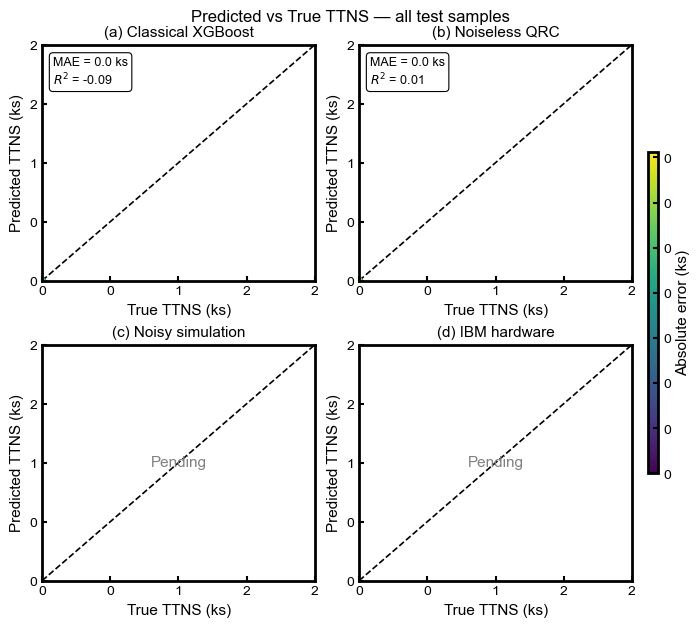

In [16]:
# ── Four-panel publication figure: Classical / Noiseless QRC / Noisy sim / Hardware
import json
import pickle
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

mpl.rcParams.update({
    'font.family':       'Arial',
    'font.size':         11,
    'axes.linewidth':    2,
    'axes.edgecolor':    'black',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.grid':         False,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'font.style':        'normal',
    'font.weight':       'normal',
    'axes.titleweight':  'normal',
    'axes.labelweight':  'normal',
})

# ── Data preparation ──────────────────────────────────────────────────────────
y_true = np.array(y_test_np)

# Classical XGBoost — from constrained pipeline
classical_preds  = np.array(final_predictions)
classical_errors = np.abs(classical_preds - y_true)

# Noiseless QRC — only available if the QRC pipeline has been run
try:
    qrc_preds  = np.array(ensemble_pred)
    qrc_errors = np.abs(qrc_preds - y_true)
    _qrc_available = True
except NameError:
    qrc_preds  = None
    qrc_errors = None
    _qrc_available = False
    print("Note: ensemble_pred not found — QRC panel will show 'Pending'.")


def _repo_root_from_cwd():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "Classical" / "results").exists():
            return candidate
    return cwd


REPO_ROOT = _repo_root_from_cwd()
NOISY_RESULT_DIR = REPO_ROOT / "Classical" / "results" / "exp1_6q_corr_noise"
HARDWARE_RESULT_DIR = REPO_ROOT / "Classical" / "results" / "hardware_qrc_run"


@dataclass
class _ReservoirParamsCompat:
    J: object
    h: float
    t: float


@dataclass
class _CandidateConfigCompat:
    candidate_id: int
    short_params: object
    long_params: object
    seed: int


class _HardwareCompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "__main__" and name == "ReservoirParams":
            return _ReservoirParamsCompat
        if module == "__main__" and name == "CandidateConfig":
            return _CandidateConfigCompat
        return super().find_class(module, name)


def _pickle_load_with_hardware_compat(path):
    with path.open("rb") as f:
        return _HardwareCompatUnpickler(f).load()


def _make_hybrid_features_decay(P_matrix, n_total_events, n_obs, decay=0.3):
    weights = np.array([
        np.exp(-decay * (n_total_events - 1 - i))
        for i in range(n_total_events)
    ])
    weights /= weights.sum()
    weighted = P_matrix.copy()
    for event_idx in range(n_total_events):
        s = event_idx * n_obs
        e = s + n_obs
        weighted[:, s:e] *= weights[event_idx]
    return weighted


def _xgb_params_from_saved(saved_params, seed):
    params = {
        "objective": "reg:squarederror",
        "n_estimators": 1200,
        "random_state": seed,
        "early_stopping_rounds": 50,
        "tree_method": "hist",
    }
    params.update(saved_params)
    return params


def _fit_saved_head(X_train, y_train, X_val, y_val, params):
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return model


def _summary_file_tag(summary):
    noise_label = summary.get("noise_spec", {}).get("label")
    packing = summary.get("packing", {})
    packing_label = packing.get("label")
    if packing.get("mode", "single") == "single":
        return noise_label
    return f"{packing_label}_{noise_label}"


def _load_noisy_sim_predictions(result_dir=NOISY_RESULT_DIR):
    summary_paths = sorted(result_dir.glob("aggregate_summary*.json"))
    if not summary_paths:
        raise FileNotFoundError(f"No aggregate_summary*.json files found in {result_dir}")

    with summary_paths[0].open("r", encoding="utf-8") as f:
        summary = json.load(f)

    tag = _summary_file_tag(summary)
    hardware_path = result_dir / f"hardware_config_{tag}.pkl"
    partial_dir = result_dir / "partials" / tag
    if not hardware_path.exists() or not partial_dir.exists():
        raise FileNotFoundError(
            f"Missing noisy prediction artifacts: {hardware_path} or {partial_dir}"
        )

    with hardware_path.open("rb") as f:
        hardware_cfg = pickle.load(f)

    cfg = hardware_cfg.get("pipeline_config", {})
    threshold = hardware_cfg.get("short_threshold", cfg.get("short_threshold", 65000))
    top_indices = list(hardware_cfg.get("top_k_indices", summary.get("top_indices", [])))
    if not top_indices:
        raise ValueError("No top_k_indices found for noisy simulation reconstruction")

    saved_clf = hardware_cfg.get("regime_classifier")
    if saved_clf is None:
        raise ValueError("No saved regime_classifier in hardware config")
    short_test_idx_noisy = np.where(saved_clf.predict(X_test_raw) == 0)[0]
    long_test_idx_noisy = np.where(saved_clf.predict(X_test_raw) == 1)[0]
    short_mask_train_noisy = saved_clf.predict(X_train_raw) == 0
    long_mask_train_noisy = saved_clf.predict(X_train_raw) == 1
    short_mask_val_noisy = saved_clf.predict(X_val_raw) == 0
    long_mask_val_noisy = saved_clf.predict(X_val_raw) == 1

    n_total_events = int(cfg.get("n_previous_events", n_previous_events)) + 1
    n_obs = 4 * int(cfg.get("n_qubits", n_qubits_base))
    preds = []

    for iter_idx in top_indices:
        short_path = partial_dir / f"partial_iter{iter_idx}_short.pkl"
        long_path = partial_dir / f"partial_iter{iter_idx}_long.pkl"
        if not short_path.exists() or not long_path.exists():
            raise FileNotFoundError(f"Missing noisy partial pair for iteration {iter_idx}")

        with short_path.open("rb") as f:
            ps = pickle.load(f)
        with long_path.open("rb") as f:
            pl = pickle.load(f)

        H_tr_short = _make_hybrid_features_decay(ps["P_train"], n_total_events, n_obs)
        H_vl_short = _make_hybrid_features_decay(ps["P_val"], n_total_events, n_obs)
        H_te_short = _make_hybrid_features_decay(ps["P_test"], n_total_events, n_obs)
        H_tr_long = _make_hybrid_features_decay(pl["P_train"], n_total_events, n_obs)
        H_vl_long = _make_hybrid_features_decay(pl["P_val"], n_total_events, n_obs)
        H_te_long = _make_hybrid_features_decay(pl["P_test"], n_total_events, n_obs)

        saved_params = (
            hardware_cfg["xgb_params_per_iteration"].get(iter_idx)
            or hardware_cfg["xgb_params_per_iteration"].get(str(iter_idx))
        )
        if saved_params is None:
            raise KeyError(f"No saved XGBoost params for noisy iteration {iter_idx}")

        model_short = _fit_saved_head(
            H_tr_short,
            y_train_np[short_mask_train_noisy],
            H_vl_short,
            y_val_np[short_mask_val_noisy],
            _xgb_params_from_saved(saved_params["short"], int(cfg.get("random_seed", 42)) + iter_idx),
        )
        model_long = _fit_saved_head(
            H_tr_long,
            y_train_np[long_mask_train_noisy],
            H_vl_long,
            y_val_np[long_mask_val_noisy],
            _xgb_params_from_saved(saved_params["long"], int(cfg.get("random_seed", 42)) + iter_idx + 1),
        )

        pred = np.empty(len(y_true), dtype=float)
        if len(short_test_idx_noisy):
            pred[short_test_idx_noisy] = model_short.predict(H_te_short)
        if len(long_test_idx_noisy):
            pred[long_test_idx_noisy] = model_long.predict(H_te_long)
        preds.append(pred)

    return np.mean(preds, axis=0)

def _load_hardware_predictions(result_dir=HARDWARE_RESULT_DIR):
    for filename, key in (
        ("hardware_results.pkl", "ensemble_pred"),
        ("final_hardware_pipeline.pkl", "ensemble_test_pred"),
    ):
        path = result_dir / filename
        if not path.exists():
            continue
        payload = _pickle_load_with_hardware_compat(path)
        pred = np.array(payload[key], dtype=float)
        if len(pred) != len(y_true):
            raise ValueError(
                f"Hardware predictions in {path} have length {len(pred)}, expected {len(y_true)}"
            )
        return pred
    raise FileNotFoundError(f"No hardware prediction pickle found in {result_dir}")


try:
    noisy_preds = _load_noisy_sim_predictions()
    noisy_errors = np.abs(noisy_preds - y_true)
    _noisy_available = True
except Exception as exc:
    noisy_preds = None
    noisy_errors = None
    _noisy_available = False
    print(f"Note: noisy simulation panel will show 'Pending' ({exc}).")

try:
    hardware_preds = _load_hardware_predictions()
    hardware_errors = np.abs(hardware_preds - y_true)
    _hardware_available = True
except Exception as exc:
    hardware_preds = None
    hardware_errors = None
    _hardware_available = False
    print(f"Note: hardware panel will show 'Pending' ({exc}).")


# ── Axis limits ───────────────────────────────────────────────────────────────
_all_defined = [y_true, classical_preds]
if _qrc_available:
    _all_defined.append(qrc_preds)
if _noisy_available:
    _all_defined.append(noisy_preds)
if _hardware_available:
    _all_defined.append(hardware_preds)
all_vals = np.concatenate(_all_defined)
ax_min   = max(0, np.min(all_vals) - 2000)
ax_max   = np.max(all_vals) + 2000
diag     = [ax_min, ax_max]

_err_arrays = [classical_errors]
if _qrc_available:
    _err_arrays.append(qrc_errors)
if _noisy_available:
    _err_arrays.append(noisy_errors)
if _hardware_available:
    _err_arrays.append(hardware_errors)
all_errors = np.concatenate(_err_arrays)
vmin, vmax = 0, np.percentile(all_errors, 95)
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)


def scatter_error(ax, y_true, y_pred, errors, title, is_placeholder=False):
    ax.set_xlim(ax_min, ax_max)
    ax.set_ylim(ax_min, ax_max)
    ax.plot(diag, diag, color='black', linewidth=1.2,
            linestyle='--', zorder=1, label='1:1 line')

    if is_placeholder:
        ax.text(0.5, 0.5, 'Pending', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='gray')
        ax.set_title(title, fontsize=11, pad=6)
        ax.set_xlabel('True TTNS (ks)', fontsize=11)
        ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
        _format_axes_ks(ax)
        return None

    ax.scatter(y_true, y_pred, c=errors, cmap=cmap, norm=norm,
               s=20, edgecolors='none', zorder=2)

    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    ax.text(0.04, 0.95,
            f'MAE = {mae/1000:.1f} ks\n$R^2$ = {r2:.2f}',
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='black', linewidth=0.8))
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlabel('True TTNS (ks)', fontsize=11)
    ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
    _format_axes_ks(ax)
    return ax


def _format_axes_ks(ax):
    ax.xaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}')
    )
    ax.yaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}')
    )


fig, axes = plt.subplots(2, 2, figsize=(6.89, 6.0), constrained_layout=True)

scatter_error(axes[0, 0], y_true, classical_preds, classical_errors,
              '(a) Classical XGBoost')
scatter_error(axes[0, 1], y_true, qrc_preds, qrc_errors,
              '(b) Noiseless QRC', is_placeholder=not _qrc_available)
scatter_error(axes[1, 0], y_true, noisy_preds, noisy_errors,
              '(c) Noisy simulation', is_placeholder=not _noisy_available)
scatter_error(axes[1, 1], y_true, hardware_preds, hardware_errors,
              '(d) IBM hardware', is_placeholder=not _hardware_available)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02, aspect=30)
cbar.set_label('Absolute error (ks)', fontsize=11)
cbar.ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}')
)
cbar.ax.tick_params(labelsize=10)

fig.suptitle('Predicted vs True TTNS — all test samples', fontsize=12, y=1.02)
plt.show()


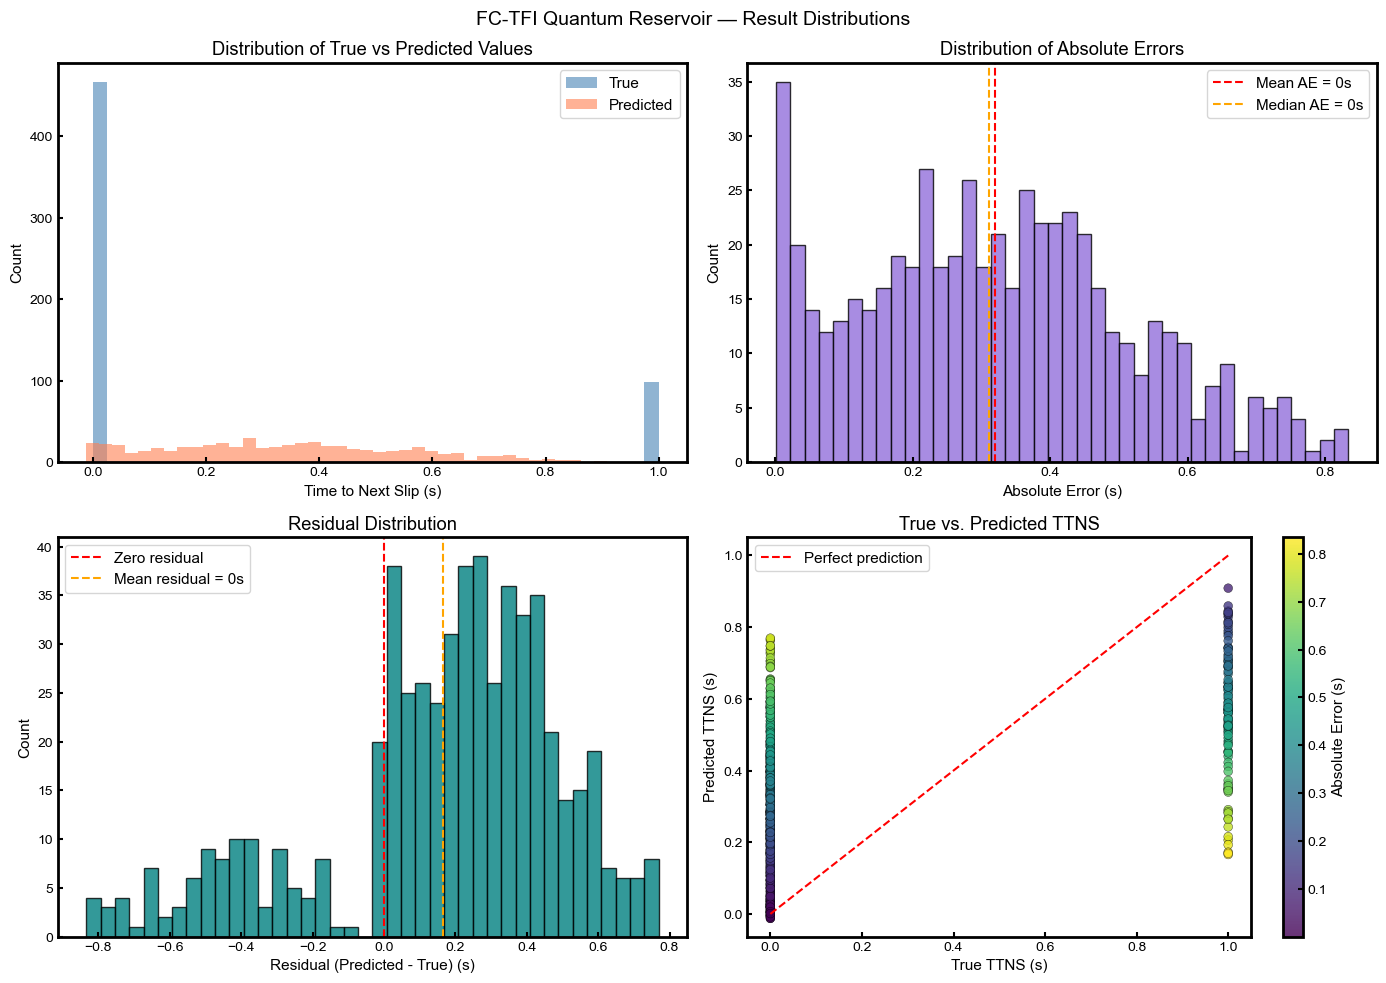

MAE:            0.32s
Median AE:      0.31s
RMSE:           0.38s
R2:             0.0149
Max error:      0.83s
% within 5000s: 100.0%
% within 9000s: 100.0%


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# ── Data distribution plot for FC-TFI run ────────────────────────────────────
y_test_secs    = y_test
QRC_pred_secs  = ensemble_pred

absolute_errors = np.abs(QRC_pred_secs - y_test_secs)
residuals       = QRC_pred_secs - y_test_secs

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FC-TFI Quantum Reservoir — Result Distributions", fontsize=14)

# ── Panel 1: Distribution of true vs predicted values ────────────────────────
axes[0, 0].hist(y_test_secs, bins=40, alpha=0.6, color='steelblue', label='True')
axes[0, 0].hist(QRC_pred_secs, bins=40, alpha=0.6, color='coral', label='Predicted')
axes[0, 0].set_xlabel("Time to Next Slip (s)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of True vs Predicted Values")
axes[0, 0].legend()

# ── Panel 2: Distribution of absolute errors ──────────────────────────────────
axes[0, 1].hist(absolute_errors, bins=40, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(absolute_errors.mean(), color='red', linestyle='--',
                    label=f'Mean AE = {absolute_errors.mean():.0f}s')
axes[0, 1].axvline(np.median(absolute_errors), color='orange', linestyle='--',
                    label=f'Median AE = {np.median(absolute_errors):.0f}s')
axes[0, 1].set_xlabel("Absolute Error (s)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution of Absolute Errors")
axes[0, 1].legend()

# ── Panel 3: Residuals distribution ──────────────────────────────────────────
axes[1, 0].hist(residuals, bins=40, color='teal', edgecolor='black', alpha=0.8)
axes[1, 0].axvline(0, color='red', linestyle='--', label='Zero residual')
axes[1, 0].axvline(residuals.mean(), color='orange', linestyle='--',
                    label=f'Mean residual = {residuals.mean():.0f}s')
axes[1, 0].set_xlabel("Residual (Predicted - True) (s)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].legend()

# ── Panel 4: True vs Predicted scatter ───────────────────────────────────────
sc = axes[1, 1].scatter(y_test_secs, QRC_pred_secs,
                         c=absolute_errors, cmap='viridis',
                         s=40, edgecolors='black', linewidths=0.3, alpha=0.8)
plt.colorbar(sc, ax=axes[1, 1], label="Absolute Error (s)")
axes[1, 1].plot([y_test_secs.min(), y_test_secs.max()],
                [y_test_secs.min(), y_test_secs.max()],
                'r--', linewidth=1.5, label='Perfect prediction')
axes[1, 1].set_xlabel("True TTNS (s)")
axes[1, 1].set_ylabel("Predicted TTNS (s)")
axes[1, 1].set_title("True vs. Predicted TTNS")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"MAE:            {mean_absolute_error(y_test_secs, QRC_pred_secs):.2f}s")
print(f"Median AE:      {np.median(absolute_errors):.2f}s")
print(f"RMSE:           {np.sqrt(np.mean(residuals**2)):.2f}s")
print(f"R2:             {r2_score(y_test_secs, QRC_pred_secs):.4f}")
print(f"Max error:      {absolute_errors.max():.2f}s")
print(f"% within 5000s: {(absolute_errors < 5000).mean()*100:.1f}%")
print(f"% within 9000s: {(absolute_errors < 9000).mean()*100:.1f}%")


  Classical XGBoost
  ──────────────────────────────────────────────────────
  Full pipeline (n=565)
    MAE  : 0 s
    R²   : -0.0875

  Noiseless QRC
  ──────────────────────────────────────────────────────
  Full pipeline (n=565)
    MAE  : 0 s
    R²   : 0.0149



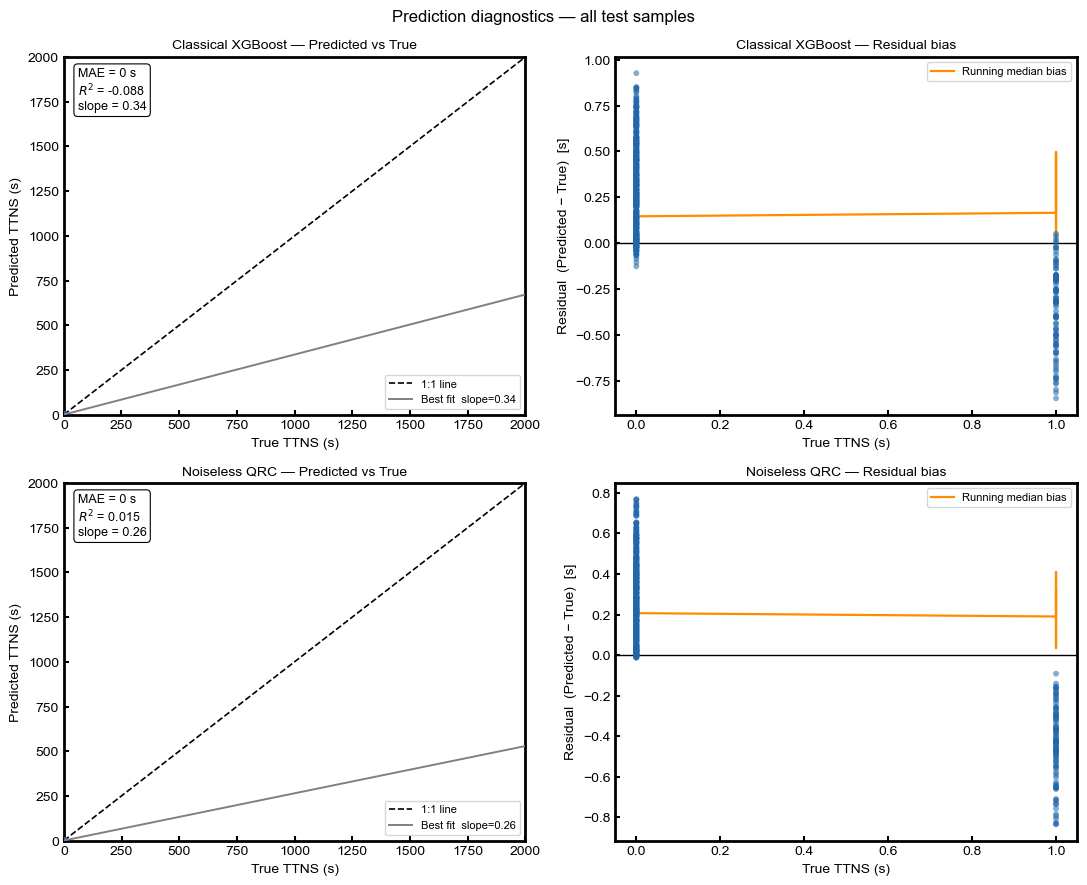

In [18]:
# ── Prediction diagnostic — scatter + residual bias plot ─────────────────

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import linregress

try:
    _qrc_preds_sc = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    _qrc_available = False

def _print_results(label, preds, y_np):
    print(f"  {label}")
    print(f"  {'─'*54}")
    print(f"  Full pipeline (n={len(y_np)})")
    print(f"    MAE  : {mean_absolute_error(y_np, preds):.0f} s")
    print(f"    R²   : {r2_score(y_np, preds):.4f}")
    print()

print("=" * 60)
_print_results("Classical XGBoost", final_predictions, y_test_np)
if _qrc_available:
    _print_results("Noiseless QRC", _qrc_preds_sc, y_test_np)
print("=" * 60)

SCATTER_COL = '#2166ac'
ALPHA = 0.55
DOT_S = 18

def _draw_pair(axes_row, y_np, preds, label):
    ax_sc, ax_res = axes_row
    signed = preds - y_np

    lim = [max(0, min(y_np.min(), preds.min()) - 2000),
           max(y_np.max(), preds.max()) + 2000]

    ax_sc.scatter(y_np, preds, color=SCATTER_COL, s=DOT_S, alpha=ALPHA,
                  edgecolors='none', zorder=3)
    ax_sc.plot(lim, lim, 'k--', lw=1.2, zorder=2, label='1:1 line')

    slope, intercept, *_ = linregress(y_np, preds)
    x_fit = np.linspace(lim[0], lim[1], 300)
    ax_sc.plot(x_fit, slope * x_fit + intercept, color='grey', lw=1.4,
               label=f'Best fit  slope={slope:.2f}', zorder=4)

    mae = mean_absolute_error(y_np, preds)
    r2  = r2_score(y_np, preds)
    ax_sc.text(0.03, 0.97,
               f'MAE = {mae:.0f} s\n$R^2$ = {r2:.3f}\nslope = {slope:.2f}',
               transform=ax_sc.transAxes, ha='left', va='top', fontsize=9,
               bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', lw=0.8))

    ax_sc.set_xlim(lim); ax_sc.set_ylim(lim)
    ax_sc.set_xlabel('True TTNS (s)', fontsize=10)
    ax_sc.set_ylabel('Predicted TTNS (s)', fontsize=10)
    ax_sc.set_title(f'{label} — Predicted vs True', fontsize=10)
    ax_sc.legend(fontsize=8, loc='lower right')

    ax_res.scatter(y_np, signed, color=SCATTER_COL, s=DOT_S, alpha=ALPHA,
                   edgecolors='none', zorder=3)
    ax_res.axhline(0, color='black', lw=1.0, zorder=2)
    sort_idx = np.argsort(y_np)
    window = max(5, len(y_np) // 20)
    running_med = np.array([
        np.median(signed[max(0, i - window // 2): min(len(signed), i + window // 2 + 1)])
        for i in range(len(signed))
    ])
    ax_res.plot(y_np[sort_idx], running_med[sort_idx], color='darkorange', lw=1.6,
                label='Running median bias')
    ax_res.set_xlabel('True TTNS (s)', fontsize=10)
    ax_res.set_ylabel('Residual  (Predicted − True)  [s]', fontsize=10)
    ax_res.set_title(f'{label} — Residual bias', fontsize=10)
    ax_res.legend(fontsize=8)

n_rows = 2 if _qrc_available else 1
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 4.5 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

_draw_pair(axes[0], y_test_np, final_predictions, 'Classical XGBoost')
if _qrc_available:
    _draw_pair(axes[1], y_test_np, _qrc_preds_sc, 'Noiseless QRC')

fig.suptitle('Prediction diagnostics — all test samples', fontsize=12)
plt.tight_layout()
plt.show()


In [19]:
# ── Additional Scatter plot — colour = signed error, size = absolute error ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import linregress

# ── Print results table ───────────────────────────────────────────────────────
try:
    _qrc_preds_sc = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    _qrc_available = False

def _print_results(label, preds, y_np, hc_idx):
    print(f"  {label}")
    print(f"  {'─'*54}")
    print(f"  All test samples (n={len(hc_idx)})")
    print(f"    MAE  : {mean_absolute_error(y_np[hc_idx], preds[hc_idx]):.0f} s")
    print(f"    R²   : {r2_score(y_np[hc_idx], preds[hc_idx]):.4f}")
    print(f"  Full pipeline (n={len(y_np)})")
    print(f"    MAE  : {mean_absolute_error(y_np, preds):.0f} s")
    print(f"    R²   : {r2_score(y_np, preds):.4f}")
    print()

print("=" * 60)
_print_results("Classical XGBoost", final_predictions, y_test_np, np.arange(len(y_test_np)))
if _qrc_available:
    _print_results("Noiseless QRC", _qrc_preds_sc, y_test_np, np.arange(len(y_test_np)))
print("=" * 60)


  Classical XGBoost
  ──────────────────────────────────────────────────────
  All test samples (n=565)
    MAE  : 0 s
    R²   : -0.0875
  Full pipeline (n=565)
    MAE  : 0 s
    R²   : -0.0875

  Noiseless QRC
  ──────────────────────────────────────────────────────
  All test samples (n=565)
    MAE  : 0 s
    R²   : 0.0149
  Full pipeline (n=565)
    MAE  : 0 s
    R²   : 0.0149



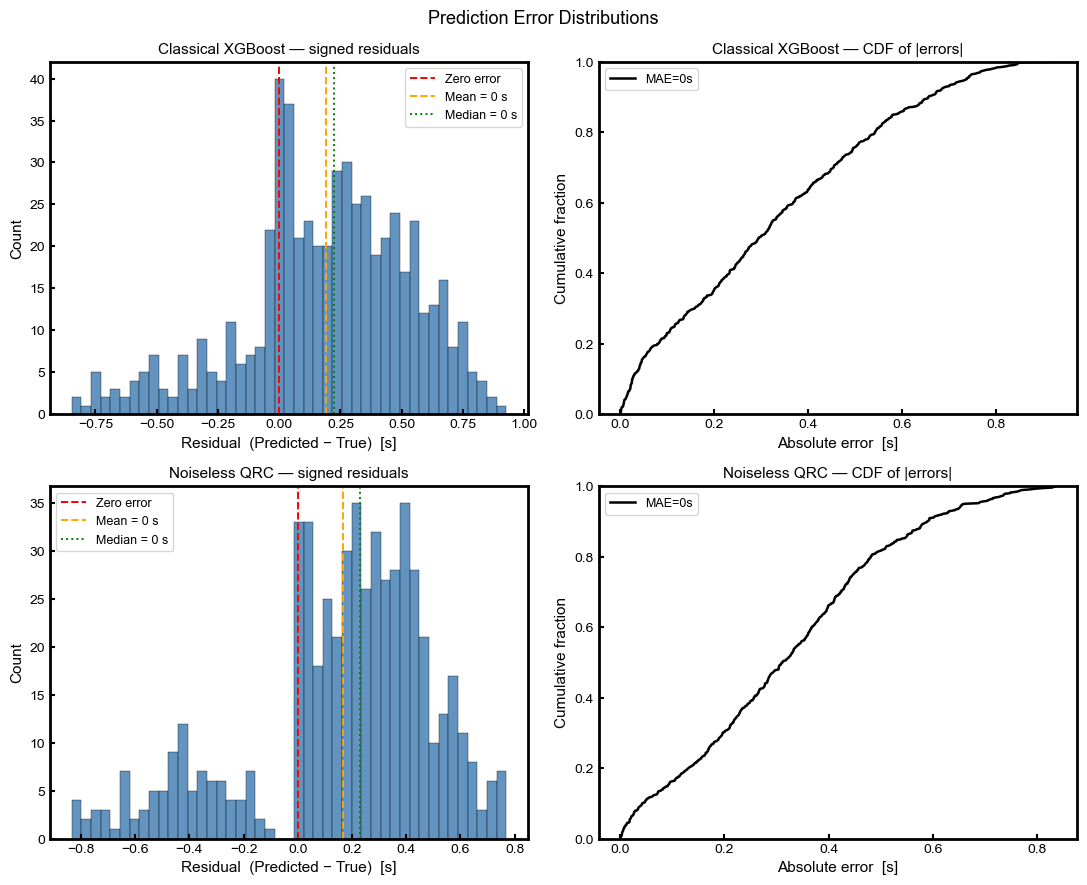

In [20]:
# ── Error distribution plots — Classical & QRC (if available) ────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

try:
    _qrc_preds_ed = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    _qrc_available = False
    print("Note: ensemble_pred not found — only classical panels shown.")

def _plot_error_dist(fig_axes, preds, label_prefix):
    axes = fig_axes
    errors_all = preds - y_test_np
    abs_err_all = np.abs(errors_all)

    ax = axes[0]
    ax.hist(errors_all, bins=45, color='steelblue', edgecolor='black',
            linewidth=0.3, alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', lw=1.4, label='Zero error')
    ax.axvline(errors_all.mean(), color='orange', linestyle='--', lw=1.4,
               label=f'Mean = {errors_all.mean():.0f} s')
    ax.axvline(np.median(errors_all), color='green', linestyle=':', lw=1.4,
               label=f'Median = {np.median(errors_all):.0f} s')
    ax.set_xlabel('Residual  (Predicted − True)  [s]', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{label_prefix} — signed residuals', fontsize=11)
    ax.legend(fontsize=9)

    ax = axes[1]
    ae = np.sort(abs_err_all)
    cdf = np.arange(1, len(ae) + 1) / len(ae)
    ax.plot(ae, cdf, color='black', lw=1.8,
            label=f'MAE={mean_absolute_error(y_test_np, preds):.0f}s')
    ax.set_xlabel('Absolute error  [s]', fontsize=11)
    ax.set_ylabel('Cumulative fraction', fontsize=11)
    ax.set_title(f'{label_prefix} — CDF of |errors|', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)


n_rows = 2 if _qrc_available else 1
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 4.5 * n_rows))
fig.suptitle('Prediction Error Distributions', fontsize=13)

if n_rows == 1:
    axes = axes[np.newaxis, :]

_plot_error_dist(axes[0], final_predictions, 'Classical XGBoost')
if _qrc_available:
    _plot_error_dist(axes[1], _qrc_preds_ed, 'Noiseless QRC')

plt.tight_layout()
plt.show()


In [21]:
# ── Per-sample results ────────────────
import pandas as pd
import numpy as np

try:
    _qrc_preds_ps = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    _qrc_available = False

row = {
    'True_TTNS_s'       : y_test_np,
    'Classical_Pred_s'  : final_predictions,
    'Classical_AbsErr_s': np.abs(final_predictions - y_test_np),
}
if _qrc_available:
    row['QRC_Pred_s']   = _qrc_preds_ps
    row['QRC_AbsErr_s'] = np.abs(_qrc_preds_ps - y_test_np)

results_df = pd.DataFrame(row)
results_df_sorted = results_df.sort_values('Classical_AbsErr_s', ascending=True).reset_index(drop=True)

print("Per-sample results (sorted by classical absolute error)")
print("=" * 80)
print(results_df_sorted.to_string(index=True, float_format=lambda x: f'{x:,.2f}'))

err_cols = ['Classical_AbsErr_s'] + (['QRC_AbsErr_s'] if _qrc_available else [])
print("\n" + "=" * 60)
print("Summary statistics:")
print(results_df[err_cols].describe().round(2))


Per-sample results (sorted by classical absolute error)
     True_TTNS_s  Classical_Pred_s  Classical_AbsErr_s  QRC_Pred_s  QRC_AbsErr_s
0              0             -0.00                0.00        0.02          0.02
1              0              0.00                0.00        0.10          0.10
2              0             -0.00                0.00        0.02          0.02
3              0             -0.00                0.00        0.01          0.01
4              0              0.00                0.00        0.00          0.00
5              0             -0.00                0.00        0.03          0.03
6              0              0.00                0.00        0.26          0.26
7              1              1.00                0.00        0.58          0.42
8              0              0.00                0.00       -0.01          0.01
9              0              0.00                0.00        0.02          0.02
10             0              0.00                0.0

Note: noisy simulation panel will show 'Pending' (No aggregate_summary*.json files found in C:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\Classical\results\exp1_6q_corr_noise).
Note: hardware panel will show 'Pending' (No hardware prediction pickle found in C:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\Classical\results\hardware_qrc_run).


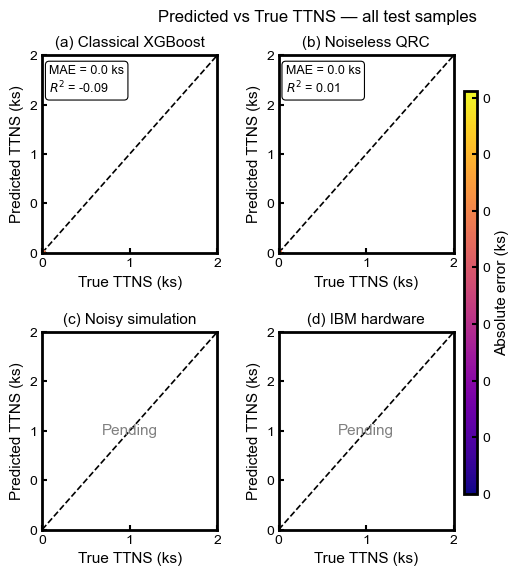

In [22]:
# ── Four-panel plot — colorbar = absolute error ──────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_error, r2_score

mpl.rcParams.update({
    'font.family':       'Arial',
    'font.size':         11,
    'axes.linewidth':    2,
    'axes.edgecolor':    'black',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.grid':         False,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
})

y_true          = np.array(y_test_np)
classical_preds = np.array(final_predictions)

try:
    qrc_preds_cd = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    qrc_preds_cd  = None
    _qrc_available = False
    print("Note: ensemble_pred not found — QRC panel will show 'Pending'.")

try:
    if "_noisy_available" in globals() and _noisy_available and noisy_preds is not None:
        noisy_preds_cd = np.array(noisy_preds)
    else:
        noisy_preds_cd = np.array(_load_noisy_sim_predictions())
    _noisy_cd_available = True
except Exception as exc:
    noisy_preds_cd = None
    _noisy_cd_available = False
    print(f"Note: noisy simulation panel will show 'Pending' ({exc}).")

try:
    if "_hardware_available" in globals() and _hardware_available and hardware_preds is not None:
        hardware_preds_cd = np.array(hardware_preds)
    else:
        hardware_preds_cd = np.array(_load_hardware_predictions())
    _hardware_cd_available = True
except Exception as exc:
    hardware_preds_cd = None
    _hardware_cd_available = False
    print(f"Note: hardware panel will show 'Pending' ({exc}).")

classical_errors = np.abs(classical_preds - y_true)
qrc_errors = np.abs(qrc_preds_cd - y_true) if _qrc_available else None
noisy_errors = np.abs(noisy_preds_cd - y_true) if _noisy_cd_available else None
hardware_errors = np.abs(hardware_preds_cd - y_true) if _hardware_cd_available else None

_ref_preds = [y_true, classical_preds]
if _qrc_available:
    _ref_preds.append(qrc_preds_cd)
if _noisy_cd_available:
    _ref_preds.append(noisy_preds_cd)
if _hardware_cd_available:
    _ref_preds.append(hardware_preds_cd)
all_vals = np.concatenate(_ref_preds)
ax_min = max(0, np.min(all_vals) - 2000)
ax_max = np.max(all_vals) + 2000
diag = [ax_min, ax_max]

_err_arrays = [classical_errors]
if _qrc_available:
    _err_arrays.append(qrc_errors)
if _noisy_cd_available:
    _err_arrays.append(noisy_errors)
if _hardware_cd_available:
    _err_arrays.append(hardware_errors)
vmin_c, vmax_c = 0, np.percentile(np.concatenate(_err_arrays), 95)
cmap_c = plt.cm.plasma
norm_c = mpl.colors.Normalize(vmin=vmin_c, vmax=vmax_c)


def _fmt_ks(ax):
    ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))


def scatter_error_panel(ax, y_true, y_pred, errors, title, is_placeholder=False):
    ax.set_xlim(ax_min, ax_max)
    ax.set_ylim(ax_min, ax_max)
    ax.plot(diag, diag, color='black', linewidth=1.2, linestyle='--', zorder=1)

    if is_placeholder:
        ax.text(0.5, 0.5, 'Pending', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='gray')
        ax.set_title(title, fontsize=11, pad=6)
        ax.set_xlabel('True TTNS (ks)', fontsize=11)
        ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
        _fmt_ks(ax)
        return

    ax.scatter(y_true, y_pred, c=errors, cmap=cmap_c, norm=norm_c,
               s=20, edgecolors='none', zorder=2)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    ax.text(0.04, 0.95, f'MAE = {mae/1000:.1f} ks\n$R^2$ = {r2:.2f}',
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='black', linewidth=0.8))
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlabel('True TTNS (ks)', fontsize=11)
    ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
    _fmt_ks(ax)


fig = plt.figure(figsize=(6.89, 6.5))
gs = fig.add_gridspec(2, 2, left=0.10, right=0.82, top=0.91, bottom=0.18,
                      wspace=0.35, hspace=0.40)
axes = np.array([[fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
                 [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]])

scatter_error_panel(axes[0, 0], y_true, classical_preds, classical_errors, '(a) Classical XGBoost')
scatter_error_panel(axes[0, 1], y_true, qrc_preds_cd, qrc_errors, '(b) Noiseless QRC',
                    is_placeholder=not _qrc_available)
scatter_error_panel(axes[1, 0], y_true, noisy_preds_cd, noisy_errors, '(c) Noisy simulation',
                    is_placeholder=not _noisy_cd_available)
scatter_error_panel(axes[1, 1], y_true, hardware_preds_cd, hardware_errors, '(d) IBM hardware',
                    is_placeholder=not _hardware_cd_available)

sm = mpl.cm.ScalarMappable(cmap=cmap_c, norm=norm_c)
sm.set_array([])
cbar_c = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02, aspect=30)
cbar_c.set_label('Absolute error (ks)', fontsize=11)
cbar_c.ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
cbar_c.ax.tick_params(labelsize=10)

fig.suptitle('Predicted vs True TTNS — all test samples', fontsize=12, y=0.98)
plt.show()


Note: noisy simulation panel will show 'Pending' (No aggregate_summary*.json files found in C:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\Classical\results\exp1_6q_corr_noise).
Note: hardware panel will show 'Pending' (No hardware prediction pickle found in C:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\Classical\results\hardware_qrc_run).


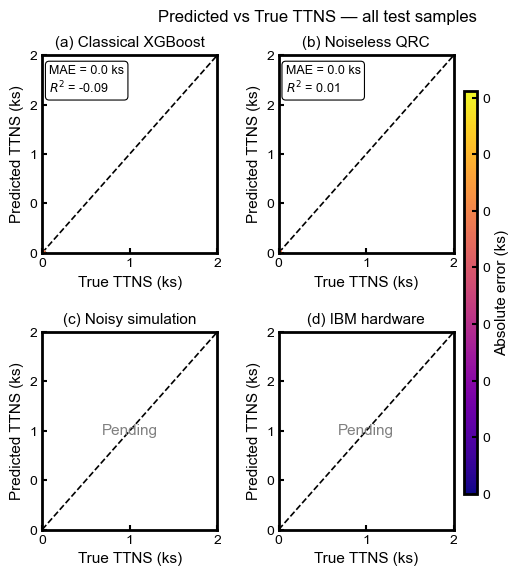

In [23]:
# ── Four-panel plot — colorbar = absolute error ──────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_error, r2_score

mpl.rcParams.update({
    'font.family':       'Arial',
    'font.size':         11,
    'axes.linewidth':    2,
    'axes.edgecolor':    'black',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.grid':         False,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
})

y_true          = np.array(y_test_np)
classical_preds = np.array(final_predictions)

try:
    qrc_preds_cd = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    qrc_preds_cd  = None
    _qrc_available = False
    print("Note: ensemble_pred not found — QRC panel will show 'Pending'.")

try:
    if "_noisy_available" in globals() and _noisy_available and noisy_preds is not None:
        noisy_preds_cd = np.array(noisy_preds)
    else:
        noisy_preds_cd = np.array(_load_noisy_sim_predictions())
    _noisy_cd_available = True
except Exception as exc:
    noisy_preds_cd = None
    _noisy_cd_available = False
    print(f"Note: noisy simulation panel will show 'Pending' ({exc}).")

try:
    if "_hardware_available" in globals() and _hardware_available and hardware_preds is not None:
        hardware_preds_cd = np.array(hardware_preds)
    else:
        hardware_preds_cd = np.array(_load_hardware_predictions())
    _hardware_cd_available = True
except Exception as exc:
    hardware_preds_cd = None
    _hardware_cd_available = False
    print(f"Note: hardware panel will show 'Pending' ({exc}).")

classical_errors = np.abs(classical_preds - y_true)
qrc_errors = np.abs(qrc_preds_cd - y_true) if _qrc_available else None
noisy_errors = np.abs(noisy_preds_cd - y_true) if _noisy_cd_available else None
hardware_errors = np.abs(hardware_preds_cd - y_true) if _hardware_cd_available else None

_ref_preds = [y_true, classical_preds]
if _qrc_available:
    _ref_preds.append(qrc_preds_cd)
if _noisy_cd_available:
    _ref_preds.append(noisy_preds_cd)
if _hardware_cd_available:
    _ref_preds.append(hardware_preds_cd)
all_vals = np.concatenate(_ref_preds)
ax_min = max(0, np.min(all_vals) - 2000)
ax_max = np.max(all_vals) + 2000
diag = [ax_min, ax_max]

_err_arrays = [classical_errors]
if _qrc_available:
    _err_arrays.append(qrc_errors)
if _noisy_cd_available:
    _err_arrays.append(noisy_errors)
if _hardware_cd_available:
    _err_arrays.append(hardware_errors)
vmin_c, vmax_c = 0, np.percentile(np.concatenate(_err_arrays), 95)
cmap_c = plt.cm.plasma
norm_c = mpl.colors.Normalize(vmin=vmin_c, vmax=vmax_c)


def _fmt_ks(ax):
    ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))


def scatter_error_panel(ax, y_true, y_pred, errors, title, is_placeholder=False):
    ax.set_xlim(ax_min, ax_max)
    ax.set_ylim(ax_min, ax_max)
    ax.plot(diag, diag, color='black', linewidth=1.2, linestyle='--', zorder=1)

    if is_placeholder:
        ax.text(0.5, 0.5, 'Pending', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='gray')
        ax.set_title(title, fontsize=11, pad=6)
        ax.set_xlabel('True TTNS (ks)', fontsize=11)
        ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
        _fmt_ks(ax)
        return

    ax.scatter(y_true, y_pred, c=errors, cmap=cmap_c, norm=norm_c,
               s=20, edgecolors='none', zorder=2)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    ax.text(0.04, 0.95, f'MAE = {mae/1000:.1f} ks\n$R^2$ = {r2:.2f}',
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='black', linewidth=0.8))
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlabel('True TTNS (ks)', fontsize=11)
    ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
    _fmt_ks(ax)


fig = plt.figure(figsize=(6.89, 6.5))
gs = fig.add_gridspec(2, 2, left=0.10, right=0.82, top=0.91, bottom=0.18,
                      wspace=0.35, hspace=0.40)
axes = np.array([[fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
                 [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]])

scatter_error_panel(axes[0, 0], y_true, classical_preds, classical_errors, '(a) Classical XGBoost')
scatter_error_panel(axes[0, 1], y_true, qrc_preds_cd, qrc_errors, '(b) Noiseless QRC',
                    is_placeholder=not _qrc_available)
scatter_error_panel(axes[1, 0], y_true, noisy_preds_cd, noisy_errors, '(c) Noisy simulation',
                    is_placeholder=not _noisy_cd_available)
scatter_error_panel(axes[1, 1], y_true, hardware_preds_cd, hardware_errors, '(d) IBM hardware',
                    is_placeholder=not _hardware_cd_available)

sm = mpl.cm.ScalarMappable(cmap=cmap_c, norm=norm_c)
sm.set_array([])
cbar_c = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02, aspect=30)
cbar_c.set_label('Absolute error (ks)', fontsize=11)
cbar_c.ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
cbar_c.ax.tick_params(labelsize=10)

fig.suptitle('Predicted vs True TTNS — all test samples', fontsize=12, y=0.98)
plt.show()


Note: noisy simulation panel will show 'Pending' (No aggregate_summary*.json files found in C:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\Classical\results\exp1_6q_corr_noise).
Note: hardware panel will show 'Pending' (No hardware prediction pickle found in C:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\Classical\results\hardware_qrc_run).


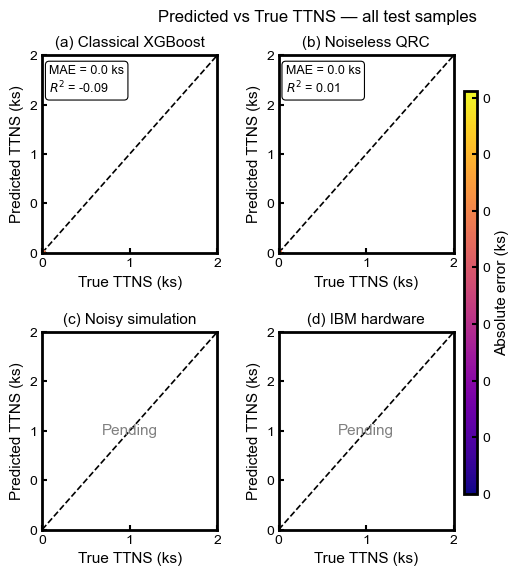

In [24]:
# ── Four-panel plot — colorbar = absolute error ──────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_error, r2_score

mpl.rcParams.update({
    'font.family':       'Arial',
    'font.size':         11,
    'axes.linewidth':    2,
    'axes.edgecolor':    'black',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.grid':         False,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
})

y_true          = np.array(y_test_np)
classical_preds = np.array(final_predictions)

try:
    qrc_preds_cd = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    qrc_preds_cd  = None
    _qrc_available = False
    print("Note: ensemble_pred not found — QRC panel will show 'Pending'.")

try:
    if "_noisy_available" in globals() and _noisy_available and noisy_preds is not None:
        noisy_preds_cd = np.array(noisy_preds)
    else:
        noisy_preds_cd = np.array(_load_noisy_sim_predictions())
    _noisy_cd_available = True
except Exception as exc:
    noisy_preds_cd = None
    _noisy_cd_available = False
    print(f"Note: noisy simulation panel will show 'Pending' ({exc}).")

try:
    if "_hardware_available" in globals() and _hardware_available and hardware_preds is not None:
        hardware_preds_cd = np.array(hardware_preds)
    else:
        hardware_preds_cd = np.array(_load_hardware_predictions())
    _hardware_cd_available = True
except Exception as exc:
    hardware_preds_cd = None
    _hardware_cd_available = False
    print(f"Note: hardware panel will show 'Pending' ({exc}).")

classical_errors = np.abs(classical_preds - y_true)
qrc_errors = np.abs(qrc_preds_cd - y_true) if _qrc_available else None
noisy_errors = np.abs(noisy_preds_cd - y_true) if _noisy_cd_available else None
hardware_errors = np.abs(hardware_preds_cd - y_true) if _hardware_cd_available else None

_ref_preds = [y_true, classical_preds]
if _qrc_available:
    _ref_preds.append(qrc_preds_cd)
if _noisy_cd_available:
    _ref_preds.append(noisy_preds_cd)
if _hardware_cd_available:
    _ref_preds.append(hardware_preds_cd)
all_vals = np.concatenate(_ref_preds)
ax_min = max(0, np.min(all_vals) - 2000)
ax_max = np.max(all_vals) + 2000
diag = [ax_min, ax_max]

_err_arrays = [classical_errors]
if _qrc_available:
    _err_arrays.append(qrc_errors)
if _noisy_cd_available:
    _err_arrays.append(noisy_errors)
if _hardware_cd_available:
    _err_arrays.append(hardware_errors)
vmin_c, vmax_c = 0, np.percentile(np.concatenate(_err_arrays), 95)
cmap_c = plt.cm.plasma
norm_c = mpl.colors.Normalize(vmin=vmin_c, vmax=vmax_c)


def _fmt_ks(ax):
    ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))


def scatter_error_panel(ax, y_true, y_pred, errors, title, is_placeholder=False):
    ax.set_xlim(ax_min, ax_max)
    ax.set_ylim(ax_min, ax_max)
    ax.plot(diag, diag, color='black', linewidth=1.2, linestyle='--', zorder=1)

    if is_placeholder:
        ax.text(0.5, 0.5, 'Pending', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='gray')
        ax.set_title(title, fontsize=11, pad=6)
        ax.set_xlabel('True TTNS (ks)', fontsize=11)
        ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
        _fmt_ks(ax)
        return

    ax.scatter(y_true, y_pred, c=errors, cmap=cmap_c, norm=norm_c,
               s=20, edgecolors='none', zorder=2)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    ax.text(0.04, 0.95, f'MAE = {mae/1000:.1f} ks\n$R^2$ = {r2:.2f}',
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='black', linewidth=0.8))
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlabel('True TTNS (ks)', fontsize=11)
    ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
    _fmt_ks(ax)


fig = plt.figure(figsize=(6.89, 6.5))
gs = fig.add_gridspec(2, 2, left=0.10, right=0.82, top=0.91, bottom=0.18,
                      wspace=0.35, hspace=0.40)
axes = np.array([[fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
                 [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]])

scatter_error_panel(axes[0, 0], y_true, classical_preds, classical_errors, '(a) Classical XGBoost')
scatter_error_panel(axes[0, 1], y_true, qrc_preds_cd, qrc_errors, '(b) Noiseless QRC',
                    is_placeholder=not _qrc_available)
scatter_error_panel(axes[1, 0], y_true, noisy_preds_cd, noisy_errors, '(c) Noisy simulation',
                    is_placeholder=not _noisy_cd_available)
scatter_error_panel(axes[1, 1], y_true, hardware_preds_cd, hardware_errors, '(d) IBM hardware',
                    is_placeholder=not _hardware_cd_available)

sm = mpl.cm.ScalarMappable(cmap=cmap_c, norm=norm_c)
sm.set_array([])
cbar_c = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02, aspect=30)
cbar_c.set_label('Absolute error (ks)', fontsize=11)
cbar_c.ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
cbar_c.ax.tick_params(labelsize=10)

fig.suptitle('Predicted vs True TTNS — all test samples', fontsize=12, y=0.98)
plt.show()
